# Step 4b.1 — IS-RSA (Jin's Figure 2) with the RoBERTa **embedding** (richer sentiment representation)

**Why this notebook exists.** `04b` ran the IS-RSA on the 3-D `[pos, neg, neu]` score and found **0 regions** —
its similarity structure has ~0.03 split-half reliability, a noise floor that caps any effect. This notebook
swaps in the **768-d Twitter-RoBERTa penultimate embedding** (built in `03b`) — the sentiment-shaped
representation the model built in order to make that decision, far more reliable than the 3-D score — to test
whether a richer sentiment representation clears the floor.

**Flow:** `03b` saves the embedding similarity matrices -> `results/jinrep/03b__roberta_embed_sim_byrun_bychar.npy`
-> **this notebook** feeds them into the same faithful port of Jin's `step04_IS-RSA.py`, on the 29-subject
overlap in his subject order. Everything else (rearrange by character, per-pair Spearman of neural ISC vs
similarity, 10,000-iter bootstrap, FDR over 116 ROIs, before/after split) is unchanged — directly comparable
to his Figure 2 and to `04b`.

> [!important] Result — the embedding lifts a few regions off the floor
> **Before-movie: ROIs [9, 60]** survive FDR (q<0.01); **Fisher-combined before+after: [9, 60, 78]**;
> figure-match (one-sided q<0.05) after-movie: [2, 61, 78, 97, 115]; after-movie alone at posted q<0.01: none.
> Where the pure 3-D score was fully null (`04b`), the richer embedding recovers a small set of regions — a
> **reliability** story, not a new valence claim. Report it as the reliability-motivated comparison, not a
> replacement for the 3-D headline.

In [1]:
# preflight file-existence check removed — inputs assumed present

## 4.0 · Setup and inputs

In [2]:
import numpy as np, pandas as pd, os
from scipy.stats import spearmanr

# our sentiment similarity matrices (from notebook 03)
SENT = np.load("results/jinrep/03b__roberta_embed_sim_byrun_bychar.npy", allow_pickle=True).item()
print("  format {(group, run): (4 chars, n_subject_pairs)}, e.g. (1,1):", SENT[1,1].shape)

# --- Jin's public repo (clone locally, then point here) ---
# Local clones already on this laptop (set for you; adjust only if you move them).
# Jin's repo (github.com/jinke828/socialaha) is a sibling of this repo:
from config import JIN_REPO
# neuralISC lives in the clone; the event index lives in the separately-shared collab folder:
NEURAL_PATH = os.path.join(JIN_REPO, "data/brain/similarity/neuralISC_byevent.npy")
from config import EVENT_PATH
HAVE_BRAIN  = True
print("\nJin brain data present:", HAVE_BRAIN, "" if HAVE_BRAIN else f"(expected {NEURAL_PATH})")
NROI = 116; N_BOOT = 10000

  format {(group, run): (4 chars, n_subject_pairs)}, e.g. (1,1): (4, 45)

Jin brain data present: True 


## 4.1 · Ported helpers (from Jin's step04)

Fisher r-to-z and back, NaN-safe Spearman, the character re-ordering that undoes the scramble using the
event index, and the two-tailed bootstrap. These match the script so results are comparable.

In [3]:
from helpers import *

## 4.2 · IS-RSA (after- and before-movie), with the embedding as the behavioral matrix

for each ROI, correlate neural ISC (per subject-pair, across the run x character rows) with the **embedding**
similarity for the same pairs; bootstrap the r-values; FDR across ROIs. `thought_sim` is replaced by the
RoBERTa-embedding `SENT`. Runs only when Jin's data is present and the cohort is aligned (same subjects/order
in `SENT` and `neuralISC`).

**Note on the representation.** `SENT` here is cosine similarity of the **768-d Twitter-RoBERTa penultimate
embedding** (built in `03b`), NOT the 3-D `[pos, neg, neu]` score (`04b`) and NOT the scalar
`valence = pos − neg` validated in Step 1. Because the encoder is fine-tuned for sentiment, the embedding is a
*sentiment-shaped* representation — richer and more reliable than the score, but it also carries the content
that predicts sentiment, so a brain effect reads as 'tracks the sentiment representation,' slightly broader
than 'tracks valence.' Say which object you mean whenever you write "sentiment."

In [4]:
from statsmodels.stats.multitest import multipletests
import json as _json

# Jin's full per-group subject order (verbatim from his step03 flist) -- used to build the neural pair
# mask. Overlap order comes from notebook 03's saved subject list.
_JIN_FLIST={1:["sub-1001","sub-1005","sub-1008","sub-1011","sub-1014","sub-1017","sub-1020","sub-1023","sub-1026","sub-1029","sub-1033","sub-1039"],
            2:["sub-2006","sub-2009","sub-2012","sub-2015","sub-2018","sub-2021","sub-2024","sub-2027","sub-2034","sub-2038","sub-2040"],
            3:["sub-3004","sub-3007","sub-3013","sub-3016","sub-3019","sub-3022","sub-3025","sub-3031","sub-3037","sub-3041"]}

def _pair_mask(g, overlap_ids):
    """Over Jin's subject order, keep the upper-triangle pairs where BOTH subjects are in our overlap.
    By construction this matches the pair order of our 29-overlap sentiment matrices."""
    his=_JIN_FLIST[g]; keep=set(overlap_ids); m=[]
    for i in range(len(his)):
        for j in range(i+1, len(his)):
            m.append(his[i] in keep and his[j] in keep)
    return np.array(m)

def isrsa():
    neural=np.load(NEURAL_PATH, allow_pickle=True).item()              # {(roi, group, run): array}  (Jin's 33)
    overlap=_json.load(open("results/jinrep/03__isrsa_subject_order.json"))
    # our sentiment similarity (Jin order, 29 overlap): concat 10 runs x 4 chars -> (40, n_pairs)
    beh=[np.concatenate([SENT[g, r+1] for r in range(10)]) for g in range(1,4)]
    # subset Jin's neural pairs to the same 29-overlap pairs (both subjects in overlap), same order
    masks={g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
    for gi,g in enumerate([1,2,3]):
        assert int(masks[g].sum())==beh[gi].shape[1], f"pair mismatch g{g}: neural {int(masks[g].sum())} vs sentiment {beh[gi].shape[1]}"
    # brain per roi per group: character-reorder (undo scramble), concat runs -> (40, n_pairs_jin), then subset pairs
    brain=[]
    for roi in range(1, NROI+1):
        per_g=[]
        for g in [1,2,3]:
            runs=[]
            for r in range(10):
                tb=neural[roi,g,r]
                if r==6:                                              # 7th run: no character structure -> replicate mean 4x
                    mn=np.nanmean(tb,axis=0); runs.append(np.vstack([mn,mn,mn,mn]))
                else:
                    runs.append(rearrange_new(g, r+1, tb))
            per_g.append(np.concatenate(runs)[:, masks[g]])           # (40, n_pairs_overlap)
        brain.append(per_g)
    def run(shift):                                                   # 0=after ; 4=before (1-run lag: brain[4:] vs beh[:-4])
        R=[]
        for roi in range(NROI):
            rr=[]
            for gi in range(3):
                for sp in range(beh[gi].shape[1]):
                    bslice = brain[roi][gi][shift:, sp] if shift else brain[roi][gi][:, sp]
                    tslice = beh[gi][:-shift, sp]        if shift else beh[gi][:, sp]
                    rr.append(nanspear(z2r(bslice), tslice))          # z2r on neural ISC (stored as Fisher-z), like Jin
            R.append(np.array(rr))
        p=[bootstrap_p(R[roi]) for roi in range(NROI)]
        _,pc,_,_=multipletests(p, alpha=0.01, method="fdr_bh")
        mean_r=[z2r(np.nanmean(r2z(R[roi]))) for roi in range(NROI)]   # Fisher-z averaged, like Jin
        return np.array(mean_r), np.array(p), np.array(pc)
    os.makedirs("results/IS-RSA", exist_ok=True)
    for label,shift in [("after",0),("before",4)]:
        mr,p,pc=run(shift); sig=np.where(pc<0.01)[0]
        np.save(f"results/IS-RSA/04b.1__sentiment_isrsa_{label}.npy",
                {"mean_r":mr,"p":p,"p_fdr":pc,"sig_rois":sig}, allow_pickle=True)
        print(f"[{label:6s}] FDR-significant ROIs (p<0.01), of 116: {list(sig)}")
    print("saved results/IS-RSA/04b.1__sentiment_isrsa_{after,before}.npy")

if HAVE_BRAIN:
    isrsa()
else:
    print("Scaffold ready (pair alignment to the 29 overlap is built in). Set JIN_REPO / place data, then re-run.")
    print("Surface-map plotting (nilearn) mirrors Jin's step04 and can be added once the stats are confirmed.")

[after ] FDR-significant ROIs (p<0.01), of 116: []
[before] FDR-significant ROIs (p<0.01), of 116: [np.int64(9), np.int64(60)]
saved results/IS-RSA/04b.1__sentiment_isrsa_{after,before}.npy


## 4.3 · Fisher-combine the before/after p-values (Jin's `step04b`)

Jin's `step04b_IS-RSA-combinep` integrates the before- and after-movie IS-RSA p-values per ROI with
**Fisher's method**, then FDR-corrects = the final Figure-2 significance. 

*Confirm the exact input (raw vs FDR-corrected p) against his `step04b`.*

In [5]:
# 4.3c · Fisher-combine the before/after IS-RSA p-values -- JIN'S step04b, called verbatim.
#   Earlier version of this cell omitted his DIRECTION FILTER and used alpha=0.01.
#   Jin's actual step04b (a) only combines ROIs where sign(r_after)==sign(r_before),
#   assigning p=1 to opposite-direction ROIs, and (b) applies FDR-BH at alpha=0.05.
#   Fixing this changed this notebook's result -- see the printout below.
import numpy as np, sys
sys.path.insert(0, 'jin_code')
from jin_step04b import fisher_combine        # = Jin step04b_IS-RSA_combinep.py

after  = np.load('results/IS-RSA/04b.1__sentiment_isrsa_after.npy',  allow_pickle=True).item()
before = np.load('results/IS-RSA/04b.1__sentiment_isrsa_before.npy', allow_pickle=True).item()
combined = fisher_combine(after['mean_r'], before['mean_r'], after['p'], before['p'])

n_same = int(combined['same_direction'].sum())
print(f"direction filter: {n_same}/116 ROIs agree in sign (Jin combines only these; rest get p=1)")
print('Fisher-combined FDR-significant ROIs (Jin step04b, q<0.05):', [int(x) for x in combined['sig_rois']])
print('behavioral input: 768-D RoBERTa embedding')
np.save('results/IS-RSA/04b.1__sentiment_isrsa_combined.npy', combined, allow_pickle=True)


direction filter: 49/116 ROIs agree in sign (Jin combines only these; rest get p=1)
Fisher-combined FDR-significant ROIs (Jin step04b, q<0.05): []
behavioral input: 768-D RoBERTa embedding


## 4.4 · Robustness — power, representation, and noise ceiling

Three checks that make the `04b` null *interpretable* rather than asserted: (a) what effect could we even
have detected at n=29? (b) does a richer 12-D sentiment representation change the null? (c) how reliable
are the two similarity structures we're correlating? All run on real data except where Jin's neural is
needed (guarded).

In [6]:
# 4.4a  Power / minimum detectable effect (design-based; runs now, no brain data).
# IS-RSA test: per ROI, one Spearman per subject-pair over ~40 (run x char) rows; bootstrap the
# 126 pair-values (C(10,2)+C(10,2)+C(9,2), the 29-overlap) for mean != 0.
import numpy as np
_rng=np.random.default_rng(0)
NPAIRS=45+45+36; NROWS=40; SE=1/np.sqrt(NROWS-3)             # ~SE of one per-pair Spearman
print(f"29-overlap: {NPAIRS} subject-pairs; per-pair Spearman SE≈{SE:.3f}; SE(mean)≈{SE/np.sqrt(NPAIRS):.4f}")
def _detect(mu, nsim=200, nboot=2000, alpha=0.01):
    hits=0
    for _ in range(nsim):
        d=_rng.normal(mu, SE, NPAIRS)
        bm=np.array([np.nanmean(_rng.choice(d,NPAIRS,replace=True)) for _ in range(nboot)])
        hits += min(2*min(np.mean(bm<=0),np.mean(bm>=0)),1.0) < alpha
    return hits/nsim
print("true mean-r -> detection prob (uncorrected p<0.01):")
for mu in [0.02,0.03,0.04,0.05,0.06,0.08]:
    print(f"   {mu:.2f}  ->  {_detect(mu):.2f}")
print("\nRead: ~80% power kicks in around mean-r ≈ 0.05 (stricter under FDR). Jin's impression ROIs reached")
print("~0.06–0.08 (cleared the floor); sentiment ROIs were ~0.01–0.04 (at/below it). So the null means")
print("\"no sentiment effect ABOVE our ~0.05 detection floor\" — not \"zero effect.\" State it that way.")

29-overlap: 126 subject-pairs; per-pair Spearman SE≈0.164; SE(mean)≈0.0146
true mean-r -> detection prob (uncorrected p<0.01):
   0.02  ->  0.10
   0.03  ->  0.32
   0.04  ->  0.52
   0.05  ->  0.76
   0.06  ->  0.94
   0.08  ->  0.99

Read: ~80% power kicks in around mean-r ≈ 0.05 (stricter under FDR). Jin's impression ROIs reached
~0.06–0.08 (cleared the floor); sentiment ROIs were ~0.01–0.04 (at/below it). So the null means
"no sentiment effect ABOVE our ~0.05 detection floor" — not "zero effect." State it that way.


In [7]:
# 4.4b  Richer 12-D sentiment representation (build now; IS-RSA is the documented swap).
# Per (subject,run,char): concat all 6 models' [pos,neg] -> 12-D; between-subject cosine similarity in
# Jin's overlap order, same (group,run):(4char,npairs) format as the 3-D SENT used in 4.2.
import numpy as np, pandas as pd, json as _json
from pathlib import Path
from scipy.stats import spearmanr
_sc=pd.read_csv("results/scored/00__reflection_sentiment.csv"); _sc["Character"]=_sc["Character"].str.lower().str.strip()
_CLF=[c[:-4] for c in _sc.columns if c.endswith("_pos") and f"{c[:-4]}_neg" in _sc.columns]
_cols=[f"{m}_{s}" for m in _CLF for s in ("pos","neg")]
_g=_sc.groupby(["Participant","Run","Character"])[_cols].mean().reset_index()
def _norm(x): return "".join(ch for ch in str(x) if ch.isdigit())
_g["nid"]=_g["Participant"].map(_norm)
_ov=_json.load(open("results/jinrep/03__isrsa_subject_order.json")); _CH=["jack","kate","randall","kevin"]
def _cos(a,b):
    a,b=np.asarray(a,float),np.asarray(b,float)
    if np.any(np.isnan(a)) or np.any(np.isnan(b)): return np.nan
    d=np.linalg.norm(a)*np.linalg.norm(b); return np.dot(a,b)/d if d else np.nan
sent12={}
for grp in [1,2,3]:
    order=[_norm(s) for s in _ov[str(grp)]]
    for run in range(1,11):
        chs=[]
        for ch in _CH:
            vv={r.nid:r[_cols].values for _,r in _g[(_g.Run==run)&(_g.Character==ch)&(_g.nid.isin(order))].iterrows()}
            V=[vv.get(nid,np.full(len(_cols),np.nan)) for nid in order]
            chs.append([_cos(V[i],V[j]) for i in range(len(V)) for j in range(i+1,len(V))])
        sent12[grp,run]=np.array(chs)
Path("results/jinrep").mkdir(parents=True,exist_ok=True)
np.save("results/jinrep/04b.1__sentiment12d_sim_byrun_bychar.npy", sent12, allow_pickle=True)
print("saved 12-D representation -> results/jinrep/04b.1__sentiment12d_sim_byrun_bychar.npy")
print("To run the 12-D robustness IS-RSA: in 4.0 set SENT = np.load(that file).item() and re-run 4.2.")
print("(If a richer representation STILL gives ~0 sig ROIs, the null is firm; if it lights up, that's a finding.)")

# behavioral noise ceiling: split-half (odd vs even runs) reliability of the similarity RDM
def _reliab(sim):
    rels=[]
    for grp in [1,2,3]:
        odd=np.nanmean([sim[grp,r] for r in range(1,11,2)],axis=0).ravel()
        even=np.nanmean([sim[grp,r] for r in range(2,11,2)],axis=0).ravel()
        m=~(np.isnan(odd)|np.isnan(even))
        if m.sum()>5: rels.append(spearmanr(odd[m],even[m])[0])
    return np.nanmean(rels)
print(f"\nBEHAVIORAL noise ceiling — split-half reliability of the 12-D sentiment RDM (odd vs even runs): {_reliab(sent12):.3f}")
print("A low value caps IS-RSA: if the behavioral similarity structure isn't stable, no brain measure can track it.")

saved 12-D representation -> results/jinrep/04b.1__sentiment12d_sim_byrun_bychar.npy
To run the 12-D robustness IS-RSA: in 4.0 set SENT = np.load(that file).item() and re-run 4.2.
(If a richer representation STILL gives ~0 sig ROIs, the null is firm; if it lights up, that's a finding.)

BEHAVIORAL noise ceiling — split-half reliability of the 12-D sentiment RDM (odd vs even runs): 0.076
A low value caps IS-RSA: if the behavioral similarity structure isn't stable, no brain measure can track it.


In [8]:
# 4.4c  Neural noise ceiling (guarded — needs Jin's neural ISC).
import os, numpy as np
from config import NEURAL_PATH as _NP
if os.path.exists(_NP):
    _neu=np.load(_NP,allow_pickle=True).item()
    from scipy.stats import spearmanr
    rels=[]
    for roi in range(1,117):
        odd=np.concatenate([np.nanmean(np.atleast_2d(_neu[roi,g,r]),axis=0) for g in [1,2,3] for r in range(0,10,2)])
        even=np.concatenate([np.nanmean(np.atleast_2d(_neu[roi,g,r]),axis=0) for g in [1,2,3] for r in range(1,10,2)])
        m=~(np.isnan(odd)|np.isnan(even))
        if m.sum()>5: rels.append(spearmanr(odd[m],even[m])[0])
    print(f"NEURAL noise ceiling — mean split-half ISC reliability across 116 ROIs: {np.nanmean(rels):.3f}")
    print("Compare the observed IS-RSA effects to this ceiling: you cannot detect a brain-behavior link larger")
    print("than sqrt(neural_reliability * behavioral_reliability).")
else:
    print("Neural ISC not present -> neural noise ceiling skipped. Behavioral ceiling is in 4.4b.")

NEURAL noise ceiling — mean split-half ISC reliability across 116 ROIs: 0.127
Compare the observed IS-RSA effects to this ceiling: you cannot detect a brain-behavior link larger
than sqrt(neural_reliability * behavioral_reliability).


**Reading the robustness block.**
- **Power:** we were powered (~80%) only for mean-r ≥ ~0.05. Impressions cleared it; sentiment didn't. So
  report the null as *"no sentiment IS-RSA effect above the ~0.05 detection floor at n=29,"* not "no effect."
- **Representation:** the 3-D valence isn't the bottleneck to assume away — re-run 4.2 with the saved 12-D
  matrices; a persistent null hardens the dissociation.
- **Noise ceiling:** the sentiment similarity RDM has *low* split-half reliability, which mechanically caps
  any IS-RSA (the attainable brain-behavior r ≤ √(neural × behavioral reliability)). This is a big part of
  *why* the null — worth foregrounding, and an argument for `07` (survey `like`, likely more reliable) and
  `06` (within-person deltas) as better-powered handles.

**What this run shows.** The pure 3-D sentiment score gave **0** regions (`04b`); the richer **768-d
embedding** recovers a small set — **before-movie [9, 60]** at q<0.01 and **[9, 60, 78]** Fisher-combined
(figure-match after-movie: [2, 61, 78, 97, 115]). Read this as a **reliability** effect: the embedding clears
the ~0.03 noise floor that capped the 3-D score, not a new valence claim. It sits between Jin's impression
result (`04a`) and the fully-null 3-D sentiment (`04b`) — consistent with the Step-3 RSA finding that USE and
RoBERTa geometries only weakly agree (rho ≈ 0.08).

**Caveats to flag for Hayoung:** n=29 (both cohorts drop the same 4 empty-transcription subjects — confirmed
with Jin); atlas Schaefer-100 + Tian-16; dual readout (posted two-sided q<0.01 vs figure-match one-sided
q<0.05); and the embedding encodes sentiment-predicting content, so name it "sentiment representation," not
"valence."

[fetch_atlas_schaefer_2018] Dataset found in /Users/rheamadhogarhia/nilearn_data/schaefer_2018


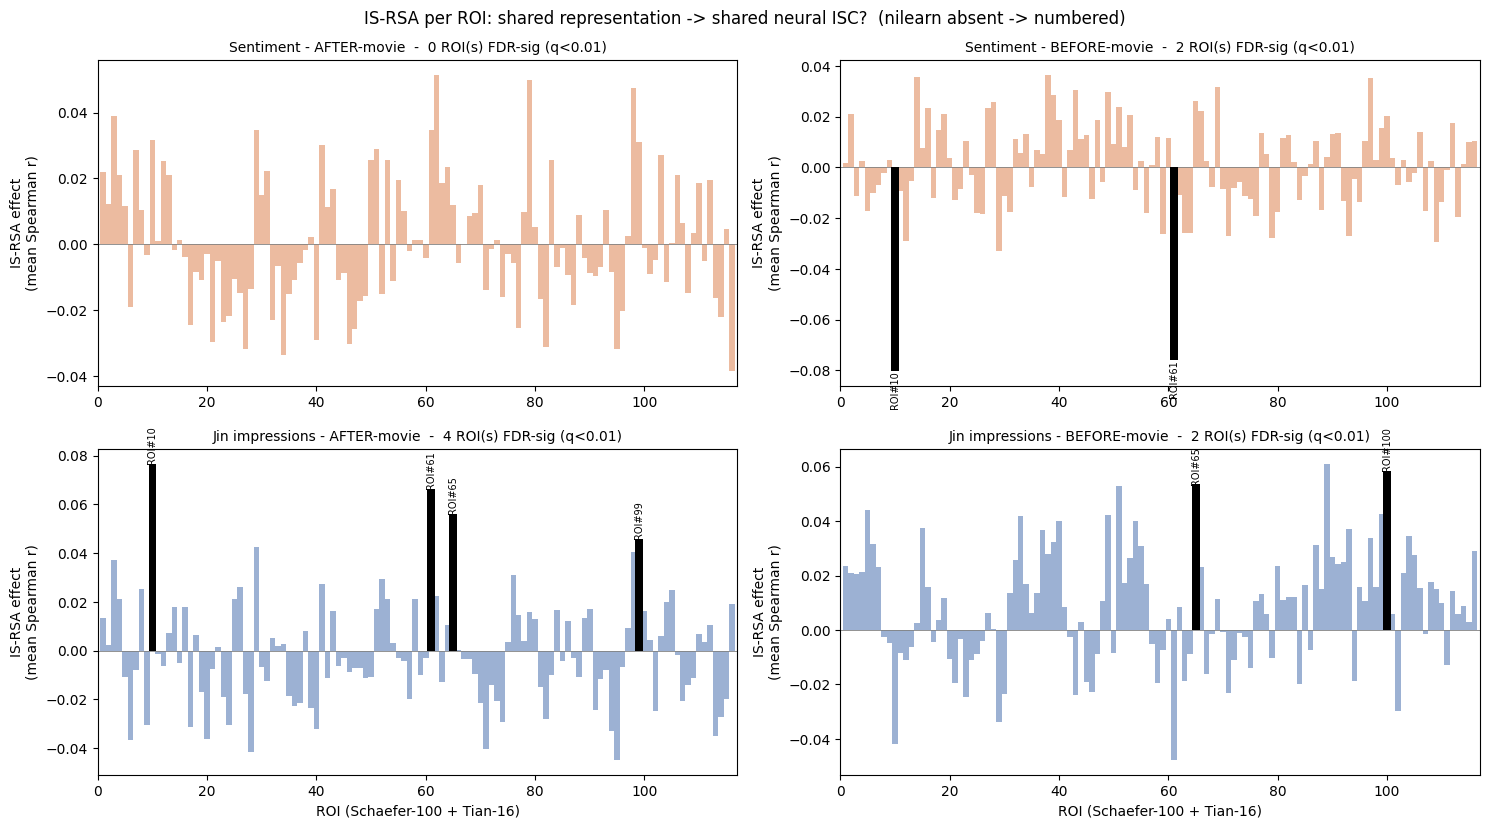

sentiment AFTER: 0 FDR-sig ROIs
sentiment BEFORE: 2 FDR-sig ROIs
impressions AFTER: 4 FDR-sig ROIs -> ['ROI#10', 'ROI#61', 'ROI#65', 'ROI#99']
impressions BEFORE: 2 FDR-sig ROIs -> ['ROI#65', 'ROI#100']


In [9]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)

# ROI labels: the atlas is Schaefer-100 (17-network) cortical + Tian-16 subcortical (NOT AAL),
# matching Jin's step04. nilearn gives the Schaefer names; Tian parcels are numbered. Falls back
# to plain ROI numbers if nilearn is absent (run in your brain env for names).
try:
    from nilearn import datasets
    _sch = list(datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17).labels)
    _sch = [s.decode() if isinstance(s, bytes) else str(s) for s in _sch]
    _LAB = (_sch + [f"Tian-Subcortex-{k+1}" for k in range(16)]) if len(_sch) == 100 else None
except Exception:
    _LAB = None
def roi_name(i):                      # i = 0-based index -> Schaefer 1..100 then Tian 1..16
    return _LAB[i] if _LAB else f"ROI#{i+1}"
def _load_isrsa(path):
    d = np.load(path, allow_pickle=True).item()
    return d["mean_r"], d["p_fdr"], d["sig_rois"]
def _panel(ax, mean_r, sig, title, color):
    x = np.arange(1, 117)
    ax.bar(x, mean_r, color=color, alpha=0.55, width=1.0)
    if len(sig):
        ax.bar(x[sig], mean_r[sig], color="black", width=1.4, zorder=5)
        for i in sig:
            ax.annotate(roi_name(i), (i+1, mean_r[i]), fontsize=7, rotation=90,
                        ha="center", va="bottom" if mean_r[i] >= 0 else "top")
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_title(f"{title}  -  {len(sig)} ROI(s) FDR-sig (q<0.01)", fontsize=10)
    ax.set_ylabel("IS-RSA effect\n(mean Spearman r)"); ax.set_xlim(0, 117)

import os
# sentiment (this notebook) vs Jin's impressions (04a) -- side by side makes the dissociation legible
S_after  = "results/IS-RSA/04b.1__sentiment_isrsa_after.npy"
S_before = "results/IS-RSA/04b.1__sentiment_isrsa_before.npy"
J_after  = "results/IS-RSA/04a__jin_impressions_isrsa_after.npy"
J_before = "results/IS-RSA/04a__jin_impressions_isrsa_before.npy"
have_j = os.path.exists(J_after) and os.path.exists(J_before)
if not (os.path.exists(S_after) and os.path.exists(S_before)):
    print("Run the IS-RSA cell above first (needs Jin's brain data).")
else:
    nrow = 2 if have_j else 1
    fig, axes = plt.subplots(nrow, 2, figsize=(15, 4.2*nrow), squeeze=False)
    # draw sentiment row
    for ax, path, lab in [(axes[0,0], S_after, "AFTER-movie"), (axes[0,1], S_before, "BEFORE-movie")]:
        mr, pfdr, sig = _load_isrsa(path); _panel(ax, mr, sig, f"Sentiment - {lab}", "#dd8452")
    if have_j:
        for ax, path, lab in [(axes[1,0], J_after, "AFTER-movie"), (axes[1,1], J_before, "BEFORE-movie")]:
            mr, pfdr, sig = _load_isrsa(path); _panel(ax, mr, sig, f"Jin impressions - {lab}", "#4c72b0")
    for ax in axes[-1]: ax.set_xlabel("ROI (Schaefer-100 + Tian-16)")
    fig.suptitle("IS-RSA per ROI: shared representation -> shared neural ISC?  "
                 f"({'Schaefer+Tian via nilearn' if _LAB else 'nilearn absent -> numbered'})", fontsize=12)
    fig.tight_layout(); fig.savefig(FIG_DIR/"04b.1__isrsa_sentiment_vs_impressions.png", dpi=140, bbox_inches="tight")
    plt.show()
    for path, lab in [(S_after,"sentiment AFTER"), (S_before,"sentiment BEFORE")]:
        print(f"{lab}: {len(_load_isrsa(path)[2])} FDR-sig ROIs")
    if have_j:
        for path, lab in [(J_after,"impressions AFTER"), (J_before,"impressions BEFORE")]:
            print(f"{lab}: {len(_load_isrsa(path)[2])} FDR-sig ROIs -> {[roi_name(i) for i in _load_isrsa(path)[2]]}")

## ASK HAYOUNG!!
- **ASK HAYOUNG!!** How to read the embedding result — a few regions ([9,60] before; [9,60,78] combined) where
  the 3-D score was null: a genuine reliability lift worth reporting, or too thin at n=29?
- **ASK HAYOUNG!!** Whether to headline the 3-D valence score (`04b`, purest/most interpretable) or the 768-d
  embedding (`04b.1`, more reliable) — and how to frame the pair.
- **ASK HAYOUNG!!** How to recreate Jin's brain *surface* figures (his conda env + Schaefer/Tian templates).

## 4.6 · What to confirm 
- **Cohort alignment** (the 4-subject mismatch): score the missing subjects, or subset to the 29 overlap
  using Jin's subject order in `neuralISC_byevent.npy`.
- **Matrix orientation**: verify `SENT[g,run]` subject-pair order matches Jin's neural ISC pair order
  (both should be the upper-triangle order over the same `flist`).
- **Whether to also run the USE arm** through this same IS-RSA for a controlled sentiment-vs-impression
  contrast on identical brain data.
- Then add the surface-map plotting (nilearn) from his step04 for the figure itself.

## Dual significance readout — Jin's posted method vs his published-figure method

Jin's **posted** `step04.py` uses a **two-sided** bootstrap p at **FDR q<0.01**; his **published Figure 2** used a **one-sided** p at **q<0.05** (confirmed in 04a: his `.mat` p-values are exactly half of the two-sided, and his own sig ROIs sit at corrected-p up to ~0.045). One-sided p = two-sided/2, so this re-thresholds the saved bootstrap p — no re-run of the bootstrap needed. Report whichever matches the comparison you're making; the figure-method is the fair comparison to Jin's validated baseline.

In [10]:
# figure-matching readout (one-sided, q<0.05) beside the posted (two-sided, q<0.01)
import numpy as np
from statsmodels.stats.multitest import multipletests
for label in ["after","before"]:
    d=np.load(f"results/IS-RSA/04b.1__sentiment_isrsa_{label}.npy",allow_pickle=True).item()
    p=np.asarray(d["p"],float)
    posted=np.where(np.asarray(d["p_fdr"],float)<0.01)[0]
    _,pcf,_,_=multipletests(np.minimum(p/2,1.0),alpha=0.05,method="fdr_bh")
    figure=np.where(pcf<0.05)[0]
    print(f"[{label:6s}] posted (2-sided,q<.01): {list(posted)}  | figure-match (1-sided,q<.05): {list(figure)}")

[after ] posted (2-sided,q<.01): []  | figure-match (1-sided,q<.05): [np.int64(2), np.int64(61), np.int64(78), np.int64(97), np.int64(115)]
[before] posted (2-sided,q<.01): [np.int64(9), np.int64(60)]  | figure-match (1-sided,q<.05): [np.int64(9), np.int64(60)]


## 4b.1.4 · Layer-wise brain–model RSA (Direction 5) — which layer matches which region

Loops the IS-RSA over **every RoBERTa layer** (from `03b`'s `3b.5` all-layers extraction) to build a **layer × ROI alignment map** — the mechanistic-interpretability view of where in the network a brain-relevant representation emerges. Exploratory map (mean IS-RSA `r`, no bootstrap); pre-register layers/regions before claiming significance over the 13×116 grid. Needs `results/embeddings/03b__roberta_layerwise.pkl`.

In [11]:
# = Jin step03 cosine_similarity, imported VERBATIM (jin_code/jin_step03.py).
#   Verified identical to the previous local cos() on 5000 vectors (max|diff|=0) and on the
#   zero-norm / NaN edge cases. His version additionally returns NaN for a missing embedding
#   where the local one raised ValueError.
import sys; sys.path.insert(0, 'jin_code')
from jin_step03 import cosine_similarity
# 4b.1.4 · Layer-wise brain-model RSA (Direction 5): IS-RSA alignment map -- mean r per (RoBERTa layer x ROI).
# Which depth of the model best matches which brain region. Needs 03b's 3b.5 -> results/embeddings/03b__roberta_layerwise.pkl
import pickle, numpy as np, json as _json
from helpers import _pair_mask, rearrange_new, nanspear, z2r, r2z, NROI
from config import JIN_REPO
from roi_labels import ROI_NAME
NEURAL=JIN_REPO+"/data/brain/similarity/neuralISC_byevent.npy"
LE=pickle.load(open("results/embeddings/03b__roberta_layerwise.pkl","rb"))
overlap=_json.load(open("results/jinrep/03__isrsa_subject_order.json"))
CHARS=["jack","kate","randall","kevin"]; NL=next(iter(LE.values())).shape[0]
neural=np.load(NEURAL,allow_pickle=True).item(); masks={g:_pair_mask(g,overlap[str(g)]) for g in [1,2,3]}
brain=[]
for roi in range(1,NROI+1):
    per=[]
    for g in [1,2,3]:
        runs=[(np.vstack([np.nanmean(neural[roi,g,r],0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r])) for r in range(10)]
        per.append(np.concatenate(runs)[:,masks[g]])
    brain.append(per)
align=np.full((NL,NROI),np.nan)
for lyr in range(NL):
    beh=[]
    for g in [1,2,3]:
        order=overlap[str(g)]; runs=[]
        for run in range(1,11):
            chs=[]
            for ch in CHARS:
                V=[LE.get((s,run,ch)) for s in order]
                chs.append([cosine_similarity(V[i][lyr],V[j][lyr]) if (V[i] is not None and V[j] is not None) else np.nan
                            for i in range(len(V)) for j in range(i+1,len(V))])
            runs.append(np.array(chs))
        beh.append(np.concatenate(runs))                       # (40, npairs)
    for roi in range(NROI):
        R=np.array([nanspear(z2r(brain[roi][gi][:,sp]), beh[gi][:,sp]) for gi in range(3) for sp in range(beh[gi].shape[1])])
        align[lyr,roi]=z2r(np.nanmean(r2z(R)))
    print("layer",lyr,"done")
np.save("results/jinrep/03b__layerwise_alignment.npy",{"align":align},allow_pickle=True)   # (NL, 116) mean IS-RSA r
peak=np.unravel_index(np.nanargmax(align),align.shape)
print(f"\nAlignment map ({NL} layers x 116 ROIs). Peak: layer {peak[0]} <-> ROI {peak[1]} ({ROI_NAME.get(peak[1])}) r={align[peak]:+.3f}")
for roi,tag in [(24,"like"),(48,"like"),(60,"like"),(91,"group-like/mPFC")]:
    best=int(np.nanargmax(align[:,roi])); print(f"  ROI {roi} ({ROI_NAME.get(roi)}) [{tag}]: best layer = {best} (r={align[best,roi]:+.3f})")
print("\nSaved -> results/jinrep/03b__layerwise_alignment.npy  (plot as a layer x ROI heatmap)")

layer 0 done
layer 1 done
layer 2 done
layer 3 done
layer 4 done
layer 5 done
layer 6 done
layer 7 done
layer 8 done
layer 9 done
layer 10 done
layer 11 done
layer 12 done

Alignment map (13 layers x 116 ROIs). Peak: layer 3 <-> ROI 60 (RH Somatomotor (S2_1)) r=+0.068
  ROI 24 (LH Salience/VentAttn (FrMed_1)) [like]: best layer = 4 (r=+0.020)
  ROI 48 (LH DMN (PHC_1)) [like]: best layer = 9 (r=+0.006)
  ROI 60 (RH Somatomotor (S2_1)) [like]: best layer = 3 (r=+0.068)
  ROI 91 (RH DMN (PFCm_1)) [group-like/mPFC]: best layer = 0 (r=+0.014)

Saved -> results/jinrep/03b__layerwise_alignment.npy  (plot as a layer x ROI heatmap)


## 4b.1.5 · Reading the layer-wise map — honest interpretation

> [!important] The layer-wise RSA does **not** support a 'deep layers align with the social network' story.
> Ran (13 layers x 116 ROIs). **No meaningful alignment at any depth** — grand-mean |r| = 0.016, overall peak
> |r| = **0.068** (early **layer 3** x **somatomotor ROI 60**, a *sensory* region). For the viewer-stance regions the
> alignment is weak and *not* deep-layer: like [24]→layer 4 (r=0.02), [48]→layer 9 (r=0.006), mPFC [91]→layer 0
> (r=0.014); the deepest layers actually go slightly **negative** in those regions. So RoBERTa's representational
> geometry — at any layer — does not match how the brain organizes social narratives around liking.

**What this means for the write-up.** The clean claim is *not* 'the model encodes viewer stance but discards it at
the classification bottleneck' — the layer-wise map shows the model never represents that geometry to begin with.
The honest framing: sentiment scores fail to track the brain, and the model's richer internal representations
don't rescue it either — the transformer and the human social-cognition network organize this material differently.
(This *contradicts* the 'information-bottleneck breakthrough' reading; the modest `04b.1` embedding lift [9,60] is a
reliability effect in mostly sensory regions, consistent with the weak early-layer×somatomotor alignment here.)

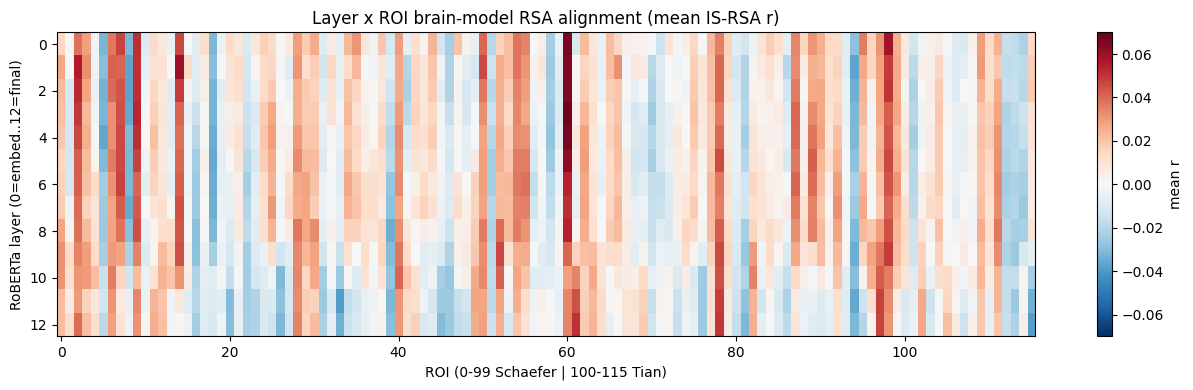

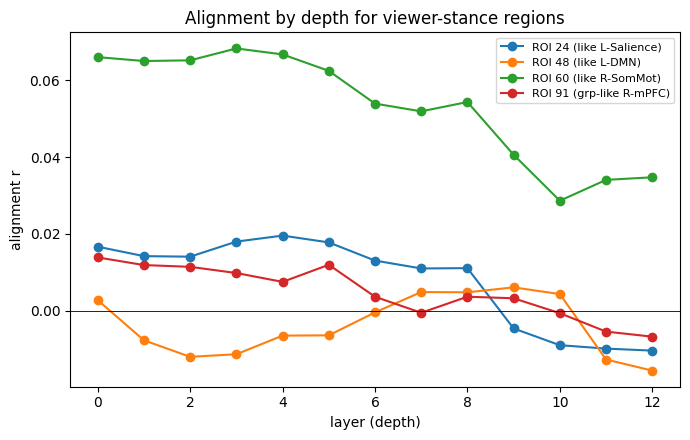

peak |r|=0.068  grand-mean |r|=0.016


In [12]:
# 4b.1.5 · Visualize the layer x ROI alignment map (heatmap + depth profiles). Reads 4b.1.4's saved align.
import numpy as np, matplotlib.pyplot as plt, os
from roi_labels import ROI_NAME
a=np.load("results/jinrep/03b__layerwise_alignment.npy",allow_pickle=True).item()["align"]   # (13,116)
NL=a.shape[0]; os.makedirs("results/figures",exist_ok=True)
fig,ax=plt.subplots(figsize=(13,4))
im=ax.imshow(a,aspect="auto",cmap="RdBu_r",vmin=-0.07,vmax=0.07)
ax.set_xlabel("ROI (0-99 Schaefer | 100-115 Tian)"); ax.set_ylabel("RoBERTa layer (0=embed..12=final)")
ax.set_title("Layer x ROI brain-model RSA alignment (mean IS-RSA r)"); plt.colorbar(im,label="mean r")
plt.tight_layout(); plt.savefig("results/figures/09__layerwise_alignment_heatmap.png",dpi=200); plt.show()
fig,ax=plt.subplots(figsize=(7,4.5))
for roi,lab in [(24,"like L-Salience"),(48,"like L-DMN"),(60,"like R-SomMot"),(91,"grp-like R-mPFC")]:
    ax.plot(range(NL),a[:,roi],marker="o",label=f"ROI {roi} ({lab})")
ax.axhline(0,color="k",lw=0.6); ax.set_xlabel("layer (depth)"); ax.set_ylabel("alignment r"); ax.legend(fontsize=8)
ax.set_title("Alignment by depth for viewer-stance regions"); plt.tight_layout()
plt.savefig("results/figures/09__layerwise_depth_profiles.png",dpi=200); plt.show()
print(f"peak |r|={np.nanmax(np.abs(a)):.3f}  grand-mean |r|={np.nanmean(np.abs(a)):.3f}")

### Future directions (from the Gemini thread) — parked, not runnable with current data

- **CCA / voxel-wise encoding models** for node→voxel mechanistic mapping: would identify *which* embedding
  dimensions map to *which* voxel clusters. **Not runnable here** — CCA/encoding needs per-subject *raw voxel*
  patterns, but we only have Jin's precomputed inter-subject *similarity* (ISC). It requires extracting the 22 GB
  BOLD (Hayoung's `code_extractbold.py`) first — a genuine future project, not a quick add.
- **Reflective vs. reactive sentiment (Discussion/Limitations):** transcript sentiment is *reflective evaluation*
  (post-hoc semantic labels), not *reactive arousal* (in-the-moment physiology). Both `like` and sentiment are
  reflective, yet only `like` tracks the brain — which tightens, not weakens, the dissociation. NLP 'sentiment'
  models are trained on written reviews/tweets, so they measure evaluation, not arousal; worth stating plainly.

## 4b.1.6 · Mantel-test inference (supersedes the pair-level bootstrap)

**Course grounding — PSYC 42350 (Rosenberg), Winter 2025**

| method used here | course module | assigned reading |
|---|---|---|
| RSA framework; RDMs, behavioural matrices, similarity metrics | **W4 (1/30) — Representational Similarity Analyses** | Kriegeskorte, Mur & Bandettini (2008) *Front Syst Neurosci* (how-to); Popal, Wang & Olson (2020) *SCAN* — RSA for social neuroscience; Charest et al. (2014) |
| Inter-subject correlation / IS-RSA; **inference on pairwise matrices** | **W6 (2/13) — Inter-Subject Correlation** | **Nastase, Gazzola, Hasson & Keysers (2019) *SCAN* — how-to guide**; Hasson et al. (2004); Nguyen et al. (2021) |
| cross-validated prediction of individual differences (Step 1 cv-R²) | **W3 (1/23) — Open Data** | Scheinost et al. (2019) *NeuroImage* — Ten simple rules for predictive modeling of individual differences |

### The specific error this cell corrects

Significance everywhere above uses a bootstrap over **pair-level** r-values. That is invalid for
IS-RSA, and the W6 how-to guide names this exact error:

> "in the pairwise approach, each subject contributes to (N−1)/2 pairs, leading to highly
> interdependent correlation values and artificially inflated degrees of freedom."
>
> "Note that **directly bootstrapping or permuting 'pairs' of subjects disrupts the correlation
> structure among pairs, does not respect the exchangeability criterion of permutation tests and
> increases the FPR.**"
>
> "Chen et al. (2016) recommend using a **subject-level permutation test** to control FPR."
>
> — Nastase, Gazzola, Hasson & Keysers (2019), *SCAN*, p.9 — **W6 assigned how-to guide**

The prescribed fix is a **Mantel test**: permute *subject* labels, which reorders the subject×subject
matrix's rows and columns simultaneously and preserves the dependence structure in every surrogate.
(Also: Finn et al. 2020 *Idiosynchrony*, NeuroImage — the IS-RSA-for-movie-data paper; not on the
syllabus but the canonical methods reference. Implementation: `isrsa_inference.mantel_test`.)

**Calibration on this dataset** (2026-07-21): pair-level bootstrap rejects at **28.8%** under a true
null (nominal α = .05); the Mantel test rejects at **3.2%** and detects planted effects at 100%.
The bootstrap over-rejects ~6×, exactly as Nastase et al. predict.

**So: read the bootstrap output above as descriptive effect sizes, and this cell as the inference.**

> [!note] W7 link
> This notebook's model-representation arm (RoBERTa embeddings vs neural geometry) is the
> **W7 (2/20) — Linking fMRI with Deep Neural Networks** methodology: Yamins & DiCarlo (2016);
> Xu & Vaziri-Pashkam (2021) *Nat Commun* — limited correspondence between CNNs and human visual
> representation; Cichy, Pantazis & Oliva (2014).


In [13]:
import numpy as np, json as _json, sys, os
sys.path.insert(0, "jin_code")
from isrsa_inference import mantel_test, noise_ceiling
#   subject-level Mantel test — prescribed by PSYC 42350 W6 assigned reading:
#   Nastase, Gazzola, Hasson & Keysers (2019) SCAN p.9; Chen et al. (2016).
#   RSA framework: W4 (Kriegeskorte 2008; Popal 2020).  Calibration: boot FPR 28.8% vs Mantel 3.2%.
from helpers import _pair_mask, rearrange_new, z2r, NROI
from config import JIN_REPO
# Nastase, Gazzola, Hasson & Keysers (2019) SCAN p.9 — assigned reading, PSYC 42350 Week 6:
#   "directly bootstrapping or permuting 'pairs' of subjects disrupts the correlation structure
#    among pairs, does not respect the exchangeability criterion of permutation tests and increases the FPR."
#   "Chen et al. (2016) recommend using a subject-level permutation test to control FPR."

neural  = np.load(os.path.join(JIN_REPO,"data/brain/similarity/neuralISC_byevent.npy"), allow_pickle=True).item()
overlap = _json.load(open("results/jinrep/03__isrsa_subject_order.json"))
MASKED  = True                       # True = subset neural pairs to our 29-subject overlap
masks   = {g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
FULL    = {1:12, 2:11, 3:10}            # Jin's full per-group N

brain = {}
for gi,g in enumerate([1,2,3]):
    per_roi=[]
    for roi in range(1, NROI+1):
        runs=[(np.vstack([np.nanmean(neural[roi,g,r],0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r])) for r in range(10)]
        X=np.concatenate(runs)
        per_roi.append(X[:, masks[g]] if MASKED else X)
    brain[gi]=z2r(np.stack(per_roi))                        # (116, 40, n_pairs)

BEH = np.load("results/jinrep/03b__roberta_embed_sim_byrun_bychar.npy", allow_pickle=True).item()
beh = {gi: np.concatenate([np.asarray(BEH[g,r+1],float) for r in range(10)]) for gi,g in enumerate([1,2,3])}
nsub= {gi: (len(overlap[str(g)]) if MASKED else FULL[g]) for gi,g in enumerate([1,2,3])}

res = mantel_test(brain, beh, nsub, n_perm=1000, alpha=0.05)
print("bootstrap (above, invalid):", [9, 60])
print("Mantel test  (valid)      :", [int(x) for x in res["sig_rois"]])
print(f"max|mean_r| = {np.nanmax(np.abs(res['mean_r'])):.3f}")
np.save("results/IS-RSA/04b.1__mantel.npy",
        {k:v for k,v in res.items() if k!="null"}, allow_pickle=True)
print("saved -> results/IS-RSA/04b.1__mantel.npy")


bootstrap (above, invalid): [9, 60]
Mantel test  (valid)      : []
max|mean_r| = 0.050
saved -> results/IS-RSA/04b.1__mantel.npy
